# Population-specific Core Microbiome Analysis

This notebook/script identifies and compares the shared and population-specific core genera in the BF and EU microbiomes.

The original study identified genera shared between BF and EU, as well as genera characteristic of each population. Here, I use a prevalence-based definition of the core microbiome to identify genera consistently present in each population and compare the shared and population-specific cores.

In [13]:
suppressPackageStartupMessages({

########### main libraries ###########
library(SummarizedExperiment)
library(TreeSummarizedExperiment)
library(mia)
library(miaViz) # mia visualizatioon

########### data manipulation tools ###########
library(tidyverse)
library(tibble)
library(scales)

########### visualization libraries ###########   
library(ggrepel)
library(patchwork)
library(scater)

library(knitr)
library(ComplexUpset)   
########### resource management tools ###########
# library(tictoc)

################ notes ####################
### loaded by tidyverse
# library(ggplot2)
# library(tidyr)
# library(dplyr)
# library(readr)
# library(stringr)

})

warnLevel <- getOption('warn')
options(warn = -1)

### Arguments Piped in with R script Conversion

In [14]:
args <- commandArgs(trailingOnly = TRUE)
if (length(args) >= 2) {
    PROJECT_NAME <- args[1]
    PROJECT_DIR  <- normalizePath(args[2])
} else {
    # defaults for notebook 
    PROJECT_NAME <- "ERP000133"
    PROJECT_DIR  <- normalizePath("..")
}

### Input File Paths (not piped in if R script)

In [15]:
ANALYSIS_DIR <- file.path(PROJECT_DIR, "analysis")
ALPHA_DIV_DIR <-  file.path(ANALYSIS_DIR, "alpha_div")


In [16]:

tse <- readRDS( file = file.path(ALPHA_DIV_DIR, paste0(PROJECT_NAME, ".tse.withAlphaDiv.rds")))
metadata <- as.data.frame(colData(tse))



### Make Output Directory

In [18]:
# make file output directory if it doesn't already exist
ANALYSIS_DIR <- file.path(PROJECT_DIR, "analysis")
CORE_MICROBIOME_DIR <-  file.path(ANALYSIS_DIR, "core_microbiome")
FIG_DIR <- file.path(PROJECT_DIR, "figures")
FIG_CORE_MICROBIOME_DIR <- file.path(FIG_DIR, "age_x_pop")
dir.create(ANALYSIS_DIR, recursive = TRUE, showWarnings = FALSE)
dir.create(CORE_MICROBIOME_DIR, recursive = TRUE, showWarnings = FALSE)
dir.create(FIG_DIR, recursive = TRUE, showWarnings = FALSE)
dir.create(FIG_CORE_MICROBIOME_DIR, recursive = TRUE, showWarnings = FALSE)

REPORT_TABLE_DIR <- file.path(PROJECT_DIR, "report_tables")
SUMMARY_TABLE_DIR <- file.path(PROJECT_DIR, "summary_tables") # more extensive tables not for the report go here
dir.create(REPORT_TABLE_DIR, recursive = TRUE, showWarnings = FALSE)
dir.create(SUMMARY_TABLE_DIR, recursive = TRUE, showWarnings = FALSE)


QUARTO_PLOT_TABLE_DIR <- file.path(PROJECT_DIR, "quarto_plot_tables")
dir.create(QUARTO_PLOT_TABLE_DIR, recursive = TRUE, showWarnings = FALSE)

### Set Global Parameters

In [48]:
population_levels <- unique(colData(tse)$population_group)
# Dynamically assign colors to values in population_group
population_levels <- unique(colData(tse)$population_group)

population_colors <- setNames(
    grDevices::hcl.colors(
        length(population_levels),
        palette = "Dark 3"
    ),
    population_levels
)

population_colors

BF        EU 
"#E16A86" "#00AD9A"

In [41]:
type(population_colors)

[1] "character"

In [138]:
# make color set

pop_core_colors <- c(
    `BF-specific core` = "#E16A86",
    `EU-specific core` = "#00AD9A", 
    `Shared core` = "#718C90"
)

In [22]:
baseSizeA = 16
titleSizeA = 18
dotSizeA = 4
axisTitleSizeA = 15
axisTextSizeA = 15
figureTitleSizeA = 25
legendTitleSizeA = 11

In [53]:
DETECTION_THRESHOLD <- 0.001   # 0.1% relative abundance

### Agglomerate to Taxa Levels

In [21]:



tse_genus <- agglomerateByRank(
    tse,
    rank = "Genus"
)

tse_genus <- transformAssay(
    tse_genus,
    assay.type = "counts",
    method = "relabundance"
)



tse_phylum <- agglomerateByRank(
    tse,
    rank = "Phylum"
)

tse_phylum <- transformAssay(
    tse_phylum,
    assay.type = "counts",
    method = "relabundance"
)



## Genus level

### Get Relative Abundances 

In [27]:
# Relative abundance matrix
rel_abund <- assay(tse_genus, "relabundance")

# Sample groups
population_group <- colData(tse_genus)$population_group


### Calculate Prevalence

In [31]:

# calc prevalence, filtered by 0.1% detection threshold
prevalence_df_genus <- tibble(
    Genus = rowData(tse_genus)$Genus,

    BF_prevalence = rowMeans(
        rel_abund[, population_group == "BF", drop = FALSE] >= DETECTION_THRESHOLD
    ),

    EU_prevalence = rowMeans(
        rel_abund[, population_group == "EU", drop = FALSE] >= DETECTION_THRESHOLD
    )
)

print(dim(prevalence_df_genus))
head(prevalence_df_genus)

[1] 163   3


Genus,BF_prevalence,EU_prevalence
<chr>,<dbl>,<dbl>
[Bacteroides] pectinophilus group,0.07142857,0.0000000
[Eubacterium] eligens group,0.28571429,0.8000000
[Eubacterium] ruminantium group,0.21428571,0.0000000
[Eubacterium] siraeum group,0.07142857,0.4000000
[Eubacterium] ventriosum group,0.14285714,0.4000000
[Eubacterium] xylanophilum group,0.00000000,0.4666667


###  Do Sensitivity Test to Find Decent 'Core Threshold' cutoff

In [59]:
core_thresholds <- c(0.50, 0.60, 0.70,  0.80, 0.90)

core_sensitivity <- bind_rows(
    lapply(core_thresholds, function(threshold) {

        prevalence_df_genus |>
            mutate(
                Core_prevalence = threshold,

                BF_core = BF_prevalence >= threshold,
                EU_core = EU_prevalence >= threshold,

                Core_status = case_when(
                    BF_core & EU_core   ~ "Shared core",
                    BF_core & !EU_core  ~ "BF-specific core",
                    !BF_core & EU_core  ~ "EU-specific core",
                    TRUE                ~ "Non-core"
                )
            )
    })
)

In [63]:
# check how many genera are core at each threshold
core_sensitivity_summary_genus <- core_sensitivity |>
    filter(Core_status != "Non-core") |>
    count(Core_prevalence, Core_status) |>
    complete(
        Core_prevalence,
        Core_status = c(
            "Shared core",
            "BF-specific core",
            "EU-specific core"
        ),
        fill = list(n = 0)
    )

core_sensitivity_summary_genus

Core_prevalence,Core_status,n
<dbl>,<chr>,<int>
0.5,BF-specific core,13
0.5,EU-specific core,17
0.5,Shared core,12
0.6,BF-specific core,8
0.6,EU-specific core,16
0.6,Shared core,8
0.7,BF-specific core,6
0.7,EU-specific core,13
0.7,Shared core,6


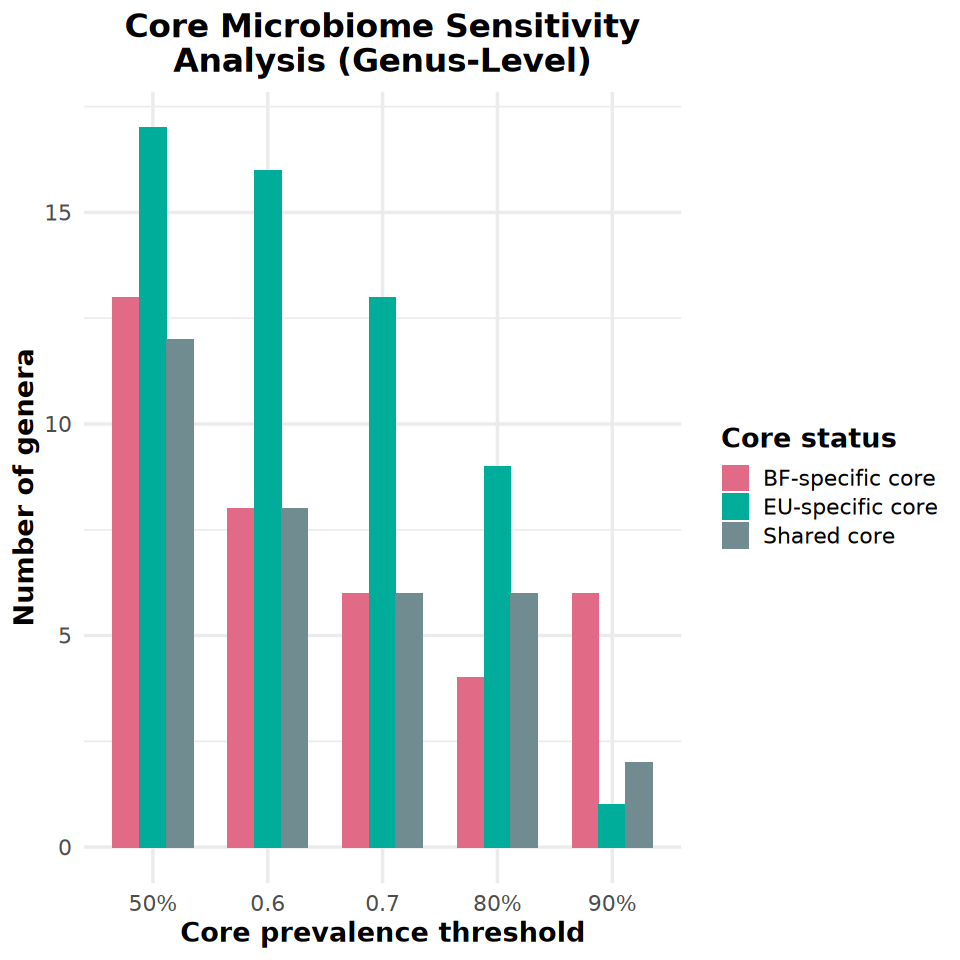

In [67]:
options(repr.plot.width = 8, repr.plot.height = 8)

p_core_sensitivity_genus <- ggplot(
    core_sensitivity_summary_genus,
    aes(
        x = factor(Core_prevalence),
        y = n,
        fill = Core_status
    )
) +
    geom_col(
        position = "dodge",
        width = 0.7
    ) +
    scale_x_discrete(
        labels = c(
            "0.5" = "50%",
            "0.8" = "80%",
            "0.9" = "90%"
        )
    ) +
    labs(
        x = "Core prevalence threshold",
        y = "Number of genera",
        fill = "Core status",
        title = "Core Microbiome Sensitivity\nAnalysis (Genus-Level)"
    ) +
    theme_minimal(base_size = 16) +
    theme(
        plot.title = element_text(
            face = "bold",
            hjust = 0.5
        ),
        axis.title = element_text(face = "bold"),
        legend.title = element_text(face = "bold")
    ) +     scale_fill_manual(values = pop_core_colors) 

p_core_sensitivity_genus

In [69]:

ggsave(
    filename = paste0(FIG_CORE_MICROBIOME_DIR, '/', PROJECT_NAME, '.core_micro.genus.sensitivity_test.png'),
    plot = p_core_sensitivity_genus,
    width = 8,
    height = 8,
    units = "in",
    dpi = 300,
    bg = "white"
)

ggsave(
    filename = paste0(FIG_CORE_MICROBIOME_DIR, '/', PROJECT_NAME, '.core_micro.genus.sensitivity_test.pdf'),
    plot = p_core_sensitivity_genus,
    width = 8,
    height = 8,
    units = "in",
    bg = "white"
)


# save table for quarto plot
write_tsv( 
    core_sensitivity_summary_genus,
    file = file.path(QUARTO_PLOT_TABLE_DIR, paste0(PROJECT_NAME, ".core_micro.genus.sensitivity_test.summary.tsv")),
    quote = "needed"
)





### Get Core Microbiomes

In [70]:
CORE_PREVALENCE_GENUS <- 0.80

In [71]:
# define the cores based on that threshold and classify 

core_df_genus <- prevalence_df_genus |>
    mutate(
        BF_core = BF_prevalence >= CORE_PREVALENCE_GENUS,
        EU_core = EU_prevalence >= CORE_PREVALENCE_GENUS,

        Core_status = case_when(
            BF_core & EU_core  ~ "Shared core",
            BF_core & !EU_core ~ "BF-specific core",
            !BF_core & EU_core ~ "EU-specific core",
            TRUE               ~ "Non-core"
        )
    )
print(dim(core_df_genus))
head(core_df_genus)

[1] 163   6


Genus,BF_prevalence,EU_prevalence,BF_core,EU_core,Core_status
<chr>,<dbl>,<dbl>,<lgl>,<lgl>,<chr>
[Bacteroides] pectinophilus group,0.07142857,0.0000000,FALSE,FALSE,Non-core
[Eubacterium] eligens group,0.28571429,0.8000000,FALSE,TRUE,EU-specific core
[Eubacterium] ruminantium group,0.21428571,0.0000000,FALSE,FALSE,Non-core
[Eubacterium] siraeum group,0.07142857,0.4000000,FALSE,FALSE,Non-core
[Eubacterium] ventriosum group,0.14285714,0.4000000,FALSE,FALSE,Non-core
[Eubacterium] xylanophilum group,0.00000000,0.4666667,FALSE,FALSE,Non-core


In [75]:
# check how many genera fall into each category 

core_df_genus_summary <- core_df_genus |>
    count(Core_status)
core_df_genus_summary

Core_status,n
<chr>,<int>
BF-specific core,4
EU-specific core,9
Non-core,144
Shared core,6


In [76]:


write_tsv( 
    core_df_genus,
    file = file.path(SUMMARY_TABLE_DIR, paste0(PROJECT_NAME, ".core_micro.genus.core_table.tsv")),
    quote = "needed"
)


write_tsv( 
    core_df_genus_summary,
    file = file.path(REPORT_TABLE_DIR, paste0(PROJECT_NAME, ".core_micro.genus.core_table_summary_counts.tsv")),
    quote = "needed"
)


### Population Specific Core 

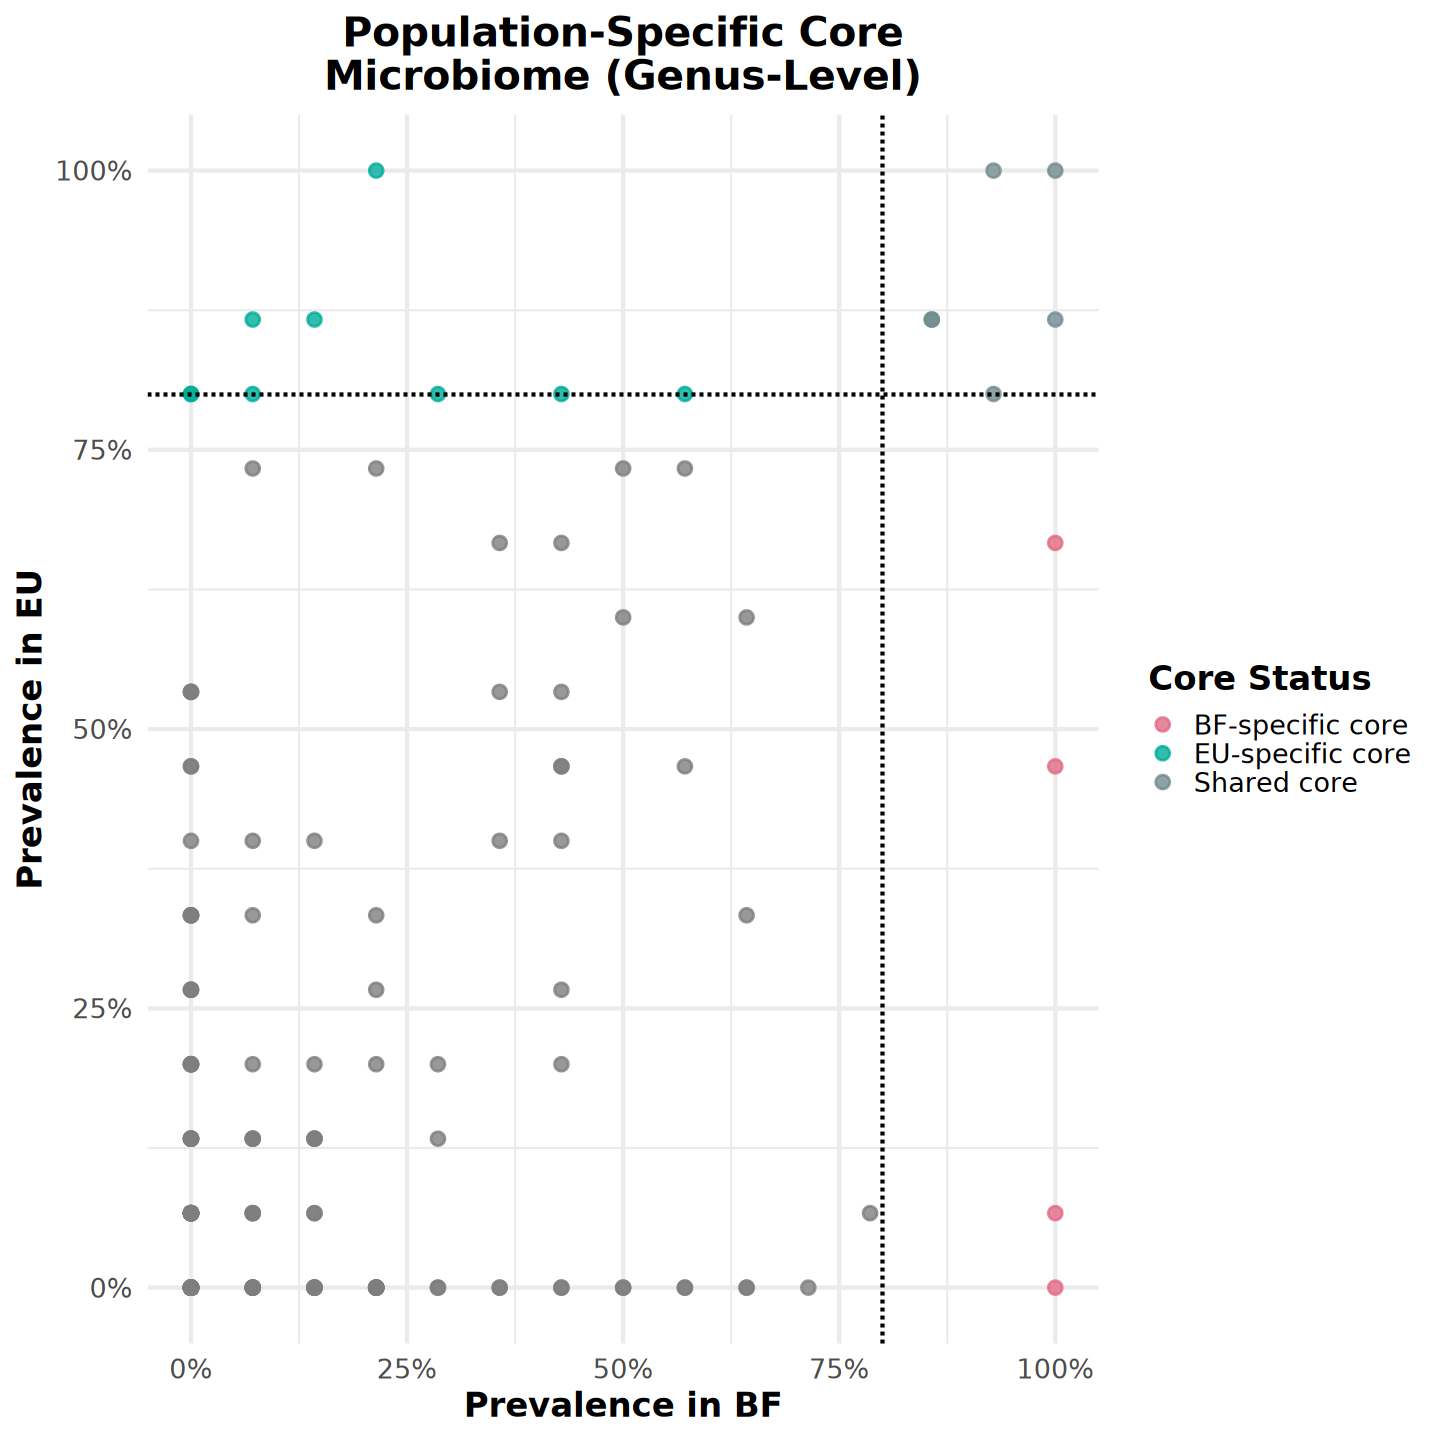

In [162]:

core_df_genus_noNA <- core_df_genus |>
    filter(!is.na(Genus))


options(repr.plot.width = 12, repr.plot.height = 12)

p_core_genus <- core_df_genus_noNA |>
    ggplot(aes(x = BF_prevalence, y = EU_prevalence, color = Core_status)) +
    geom_point(size = 3, alpha = 0.8) +
    geom_vline(xintercept = CORE_PREVALENCE, linetype = "dashed") +
    geom_hline(yintercept = CORE_PREVALENCE, linetype = "dashed") +
    scale_x_continuous(labels = scales::percent, limits = c(0, 1)) +
    scale_y_continuous(labels = scales::percent, limits = c(0, 1)) +
    scale_color_manual(values = pop_core_colors) +
    labs(
        x = "Prevalence in BF",
        y = "Prevalence in EU",
        color = "Core Status",
        title = "Population-Specific Core\nMicrobiome (Genus-Level)"
    ) +
    theme_minimal(base_size = 20) +
    theme(
        plot.title = element_text(face = "bold", hjust = 0.5),
        axis.title = element_text(face = "bold"),
        legend.title = element_text(face = "bold")
    )

p_core_genus

In [163]:





ggsave(
    filename = paste0(FIG_CORE_MICROBIOME_DIR, '/', PROJECT_NAME, '.core_micro.genus.prev.png'),
    plot = p_core_genus,
    width = 10,
    height = 9,
    units = "in",
    dpi = 300,
    bg = "white"
)

ggsave(
    filename = paste0(FIG_CORE_MICROBIOME_DIR, '/', PROJECT_NAME, '.core_micro.genus.prev.pdf'),
    plot = p_core_genus,
    width = 10,
    height = 9,
    units = "in",
    bg = "white"
)


In [79]:
# Shared core
core_df_genus |>
    filter(Core_status == "Shared core") |>
    arrange(desc(BF_prevalence + EU_prevalence))

# BF-specific core
core_df_genus |>
    filter(Core_status == "BF-specific core") |>
    arrange(desc(BF_prevalence))

# EU-specific core
core_df_genus |>
    filter(Core_status == "EU-specific core") |>
    arrange(desc(EU_prevalence))

Genus,BF_prevalence,EU_prevalence,BF_core,EU_core,Core_status
<chr>,<dbl>,<dbl>,<lgl>,<lgl>,<chr>
Faecalibacterium,1.0000000,1.0000000,TRUE,TRUE,Shared core
Blautia,0.9285714,1.0000000,TRUE,TRUE,Shared core
Gemmiger,1.0000000,0.8666667,TRUE,TRUE,Shared core
Mediterraneibacter,0.9285714,0.8000000,TRUE,TRUE,Shared core
Roseburia,0.8571429,0.8666667,TRUE,TRUE,Shared core
Streptococcus,0.8571429,0.8666667,TRUE,TRUE,Shared core


Genus,BF_prevalence,EU_prevalence,BF_core,EU_core,Core_status
<chr>,<dbl>,<dbl>,<lgl>,<lgl>,<chr>
Dialister,1,0.46666667,TRUE,FALSE,BF-specific core
Dorea,1,0.66666667,TRUE,FALSE,BF-specific core
Leyella,1,0.00000000,TRUE,FALSE,BF-specific core
Segatella,1,0.06666667,TRUE,FALSE,BF-specific core


Genus,BF_prevalence,EU_prevalence,BF_core,EU_core,Core_status
<chr>,<dbl>,<dbl>,<lgl>,<lgl>,<chr>
Bifidobacterium,0.21428571,1.0000000,FALSE,TRUE,EU-specific core
Alistipes,0.07142857,0.8666667,FALSE,TRUE,EU-specific core
Lachnospiraceae UCG-004,0.14285714,0.8666667,FALSE,TRUE,EU-specific core
[Eubacterium] eligens group,0.28571429,0.8000000,FALSE,TRUE,EU-specific core
Agathobacter,0.57142857,0.8000000,FALSE,TRUE,EU-specific core
Bacteroides,0.00000000,0.8000000,FALSE,TRUE,EU-specific core
Enterocloster,0.07142857,0.8000000,FALSE,TRUE,EU-specific core
Fusicatenibacter,0.42857143,0.8000000,FALSE,TRUE,EU-specific core
Odoribacter,0.00000000,0.8000000,FALSE,TRUE,EU-specific core


In [85]:
core_df_genus_noNA_noShared <- core_df_genus_noNA |>
    filter(BF_core | EU_core) |>
    select(Genus, BF_core, EU_core)

core_df_genus_noNA_noShared

Genus,BF_core,EU_core
<chr>,<lgl>,<lgl>
[Eubacterium] eligens group,FALSE,TRUE
Agathobacter,FALSE,TRUE
Alistipes,FALSE,TRUE
Bacteroides,FALSE,TRUE
Bifidobacterium,FALSE,TRUE
Blautia,TRUE,TRUE
Dialister,TRUE,FALSE
Dorea,TRUE,FALSE
Enterocloster,FALSE,TRUE


In [ ]:

core_df_genus_noNA_noShared <- core_df_genus_noNA_noShared |>
    filter(BF_core | EU_core) |>
    transmute(
        Genus,
        BF = BF_core,
        EU = EU_core
    )


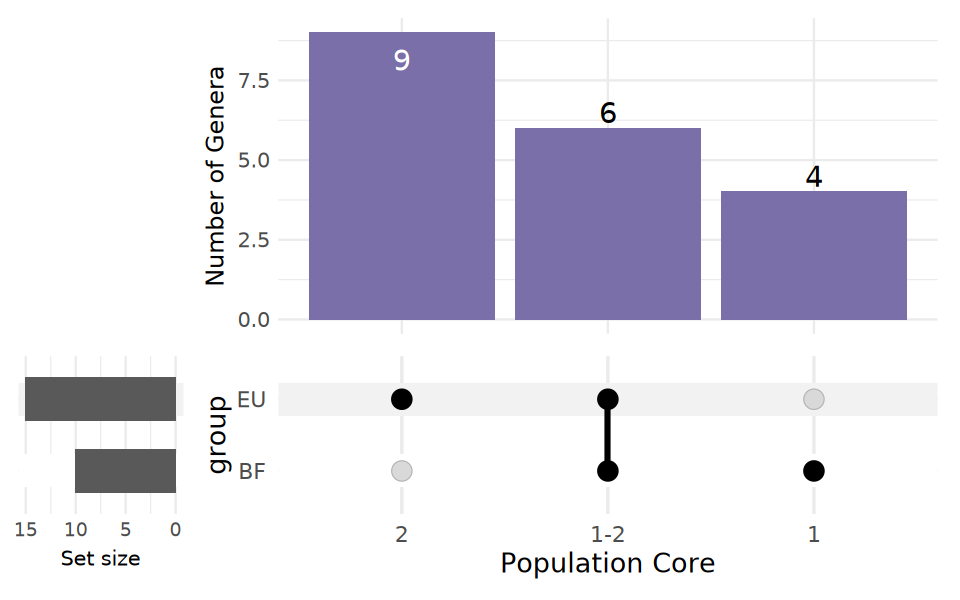

In [164]:
options(repr.plot.width = 8, repr.plot.height = 5)
p_core_upset_genus <- upset(
    core_df_genus_noNA_noShared,
    c("BF", "EU"),
    name = "Population Core",
    width_ratio = 0.2,

     base_annotations = list(
        "Number of Genera" = (
            intersection_size(fill = "#7A6FA8", 
                              text = list(size = 6)
                             ) +
            theme(
                axis.title.y = element_text( # 'number of genera'
                    size = 14,
                    # face = "bold"
                ),
                axis.text.y = element_text( # nubmer of genera ticks
                    size = 12,
                    # face = "bold"
                )
            )
        )
    ),

    matrix = intersection_matrix(
        geom = geom_point(size = 4),
        segment = geom_segment(linewidth = 1.2)
    ),

    set_sizes = (
        upset_set_size() +
        theme(
            axis.title.x = element_text( # Set Size
                size = 12,
                # face = "bold"
            ),
            axis.text.x = element_text(size = 11)
        )
    )

    
) +
    theme(
        text = element_text(size = 18, color = "black"),
        axis.text = element_text(size = 20, color = "black"),
        axis.title = element_text(size = 20, face = "bold", color = "black"),
        plot.title = element_text(size = 20, face = "bold", color = "black"),
       axis.title.y  = element_text(size = 20, face = "bold", color = "black"),
        axis.text.y = element_text(size = 22,face = "bold"),
        
        # text = list(size = 8),
        panel.grid.major = element_line(
            color = "grey70",
            linewidth = 0.6
        ),
        panel.grid.minor = element_blank()
    )   +   
theme_minimal(base_size = 16) 



p_core_upset_genus

In [165]:


ggsave(
    filename = paste0(FIG_CORE_MICROBIOME_DIR, '/', PROJECT_NAME, '.core_micro.genus.sensitivity_test.png'),
    plot = p_core_upset_genus,
    width = 8,
    height = 8,
    units = "in",
    dpi = 300,
    bg = "white"
)

ggsave(
    filename = paste0(FIG_CORE_MICROBIOME_DIR, '/', PROJECT_NAME, '.core_micro.genus.sensitivity_test.pdf'),
    plot = p_core_upset_genus,
    width = 8,
    height = 8,
    units = "in",
    bg = "white"
)


# save table for quarto plot
write_tsv( 
    core_df_genus_noNA_noShared,
    file = file.path(QUARTO_PLOT_TABLE_DIR, paste0(PROJECT_NAME, ".core_micro.genus.sensitivity_test.summary.tsv")),
    quote = "needed"
)















## Phylum level

### Get Relative Abundances 

In [141]:
# Relative abundance matrix
rel_abund <- assay(tse_phylum, "relabundance")

# Sample groups
population_group <- colData(tse_phylum)$population_group


# Relative abundance matrix
rel_abund <- assay(tse_phylum, "relabundance")

# Sample groups
population_group <- colData(tse_phylum)$population_group



### Calculate Prevalence

In [142]:


# calc prevalence, filtered by 0.1% detection threshold
prevalence_df_phylum <- tibble(
    Phylum = rowData(tse_phylum)$Phylum,

    BF_prevalence = rowMeans(
        rel_abund[, population_group == "BF", drop = FALSE] >= DETECTION_THRESHOLD
    ),

    EU_prevalence = rowMeans(
        rel_abund[, population_group == "EU", drop = FALSE] >= DETECTION_THRESHOLD
    )
)

print(dim(prevalence_df_phylum))
head(prevalence_df_phylum)


[1] 10  3


Phylum,BF_prevalence,EU_prevalence
<chr>,<dbl>,<dbl>
Actinomycetota,0.6428571,1.00000000
Bacillota,1.0000000,1.00000000
Bacteroidota,1.0000000,0.86666667
Campylobacterota,0.2142857,0.00000000
Fusobacteriota,0.0000000,0.06666667
Patescibacteria,0.1428571,0.00000000


###  Do Sensitivity Test to Find Decent 'Core Threshold' cutoff


In [143]:

core_thresholds <- c(0.50, 0.60, 0.70,  0.80, 0.90)

core_sensitivity_phylum <- bind_rows(
    lapply(core_thresholds, function(threshold) {

        prevalence_df_phylum |>
            mutate(
                Core_prevalence = threshold,

                BF_core = BF_prevalence >= threshold,
                EU_core = EU_prevalence >= threshold,

                Core_status = case_when(
                    BF_core & EU_core   ~ "Shared core",
                    BF_core & !EU_core  ~ "BF-specific core",
                    !BF_core & EU_core  ~ "EU-specific core",
                    TRUE                ~ "Non-core"
                )
            )
    })
)



In [144]:

# check how many genera are core at each threshold
core_sensitivity_summary_phylum <- core_sensitivity_phylum |>
    filter(Core_status != "Non-core") |>
    count(Core_prevalence, Core_status) |>
    complete(
        Core_prevalence,
        Core_status = c(
            "Shared core",
            "BF-specific core",
            "EU-specific core"
        ),
        fill = list(n = 0)
    )

core_sensitivity_summary_phylum



Core_prevalence,Core_status,n
<dbl>,<chr>,<int>
0.5,BF-specific core,1
0.5,EU-specific core,1
0.5,Shared core,4
0.6,BF-specific core,1
0.6,EU-specific core,1
0.6,Shared core,4
0.7,BF-specific core,0
0.7,EU-specific core,1
0.7,Shared core,3


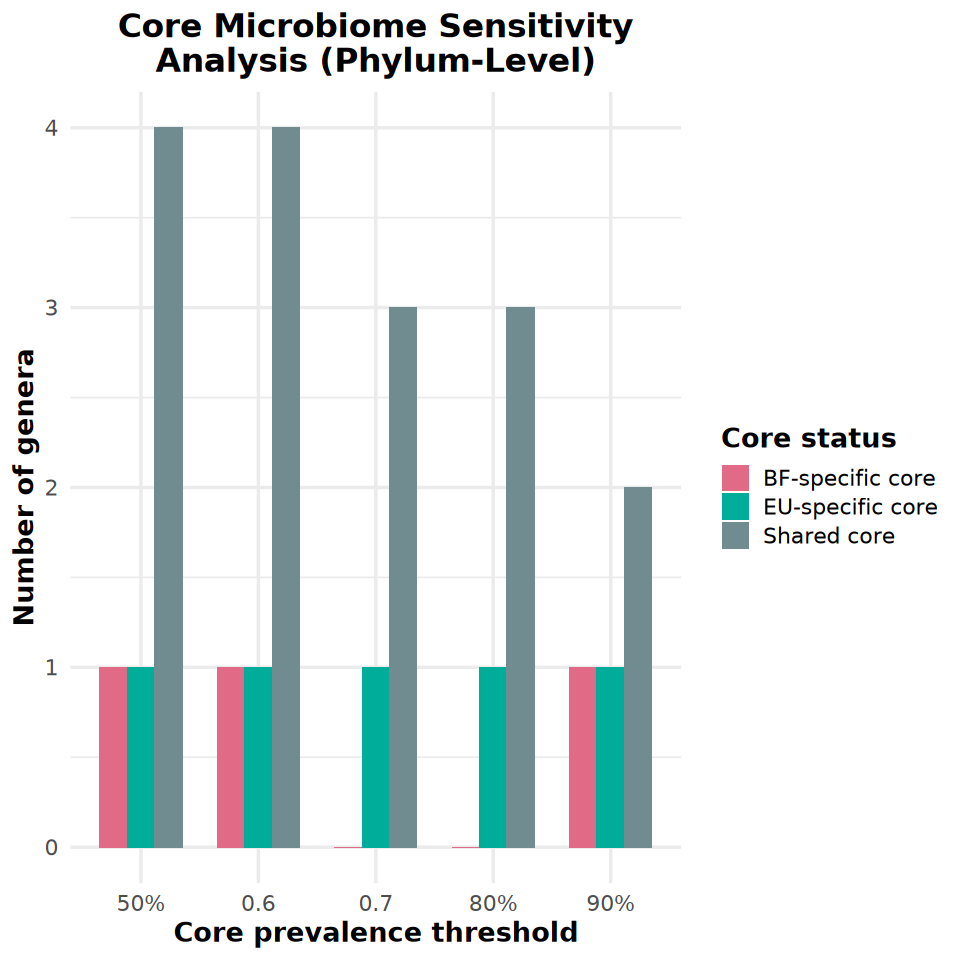

In [145]:



options(repr.plot.width = 8, repr.plot.height = 8)

p_core_sensitivity_phylum <- ggplot(
    core_sensitivity_summary_phylum,
    aes(
        x = factor(Core_prevalence),
        y = n,
        fill = Core_status
    )
) +
    geom_col(
        position = "dodge",
        width = 0.7
    ) +
    scale_x_discrete(
        labels = c(
            "0.5" = "50%",
            "0.8" = "80%",
            "0.9" = "90%"
        )
    ) +
    labs(
        x = "Core prevalence threshold",
        y = "Number of genera",
        fill = "Core status",
        title = "Core Microbiome Sensitivity\nAnalysis (Phylum-Level)"
    ) +
    theme_minimal(base_size = 16) +
    theme(
        plot.title = element_text(
            face = "bold",
            hjust = 0.5
        ),
        axis.title = element_text(face = "bold"),
        legend.title = element_text(face = "bold")
    ) +     scale_fill_manual(values = pop_core_colors) 

p_core_sensitivity_phylum




In [147]:

ggsave(
    filename = paste0(FIG_CORE_MICROBIOME_DIR, '/', PROJECT_NAME, '.core_micro.phylum.sensitivity_test.png'),
    plot = p_core_sensitivity_phylum,
    width = 8,
    height = 8,
    units = "in",
    dpi = 300,
    bg = "white"
)

ggsave(
    filename = paste0(FIG_CORE_MICROBIOME_DIR, '/', PROJECT_NAME, '.core_micro.phylum.sensitivity_test.pdf'),
    plot = p_core_sensitivity_phylum,
    width = 8,
    height = 8,
    units = "in",
    bg = "white"
)


# save table for quarto plot
write_tsv( 
    core_sensitivity_summary_phylum,
    file = file.path(QUARTO_PLOT_TABLE_DIR, paste0(PROJECT_NAME, ".core_micro.phylum.sensitivity_test.summary.tsv")),
    quote = "needed"
)





### Get Core Microbiomes

In [148]:


CORE_PREVALENCE_PHYLUM <- 0.80



# define the cores based on that threshold and classify 

core_df_phylum <- prevalence_df_phylum |>
    mutate(
        BF_core = BF_prevalence >= CORE_PREVALENCE_PHYLUM,
        EU_core = EU_prevalence >= CORE_PREVALENCE_PHYLUM,

        Core_status = case_when(
            BF_core & EU_core  ~ "Shared core",
            BF_core & !EU_core ~ "BF-specific core",
            !BF_core & EU_core ~ "EU-specific core",
            TRUE               ~ "Non-core"
        )
    )
print(dim(core_df_phylum))
head(core_df_phylum)





[1] 10  6


Phylum,BF_prevalence,EU_prevalence,BF_core,EU_core,Core_status
<chr>,<dbl>,<dbl>,<lgl>,<lgl>,<chr>
Actinomycetota,0.6428571,1.00000000,FALSE,TRUE,EU-specific core
Bacillota,1.0000000,1.00000000,TRUE,TRUE,Shared core
Bacteroidota,1.0000000,0.86666667,TRUE,TRUE,Shared core
Campylobacterota,0.2142857,0.00000000,FALSE,FALSE,Non-core
Fusobacteriota,0.0000000,0.06666667,FALSE,FALSE,Non-core
Patescibacteria,0.1428571,0.00000000,FALSE,FALSE,Non-core


In [149]:


# check how many genera fall into each category 

core_df_phylum_summary <- core_df_phylum |>
    count(Core_status)
core_df_phylum_summary


Core_status,n
<chr>,<int>
EU-specific core,1
Non-core,6
Shared core,3


In [150]:

write_tsv( 
    core_df_phylum,
    file = file.path(SUMMARY_TABLE_DIR, paste0(PROJECT_NAME, ".core_micro.phylum.core_table.tsv")),
    quote = "needed"
)


write_tsv( 
    core_df_phylum_summary,
    file = file.path(REPORT_TABLE_DIR, paste0(PROJECT_NAME, ".core_micro.phylum.core_table_summary_counts.tsv")),
    quote = "needed"
)




### Population Specific Core 


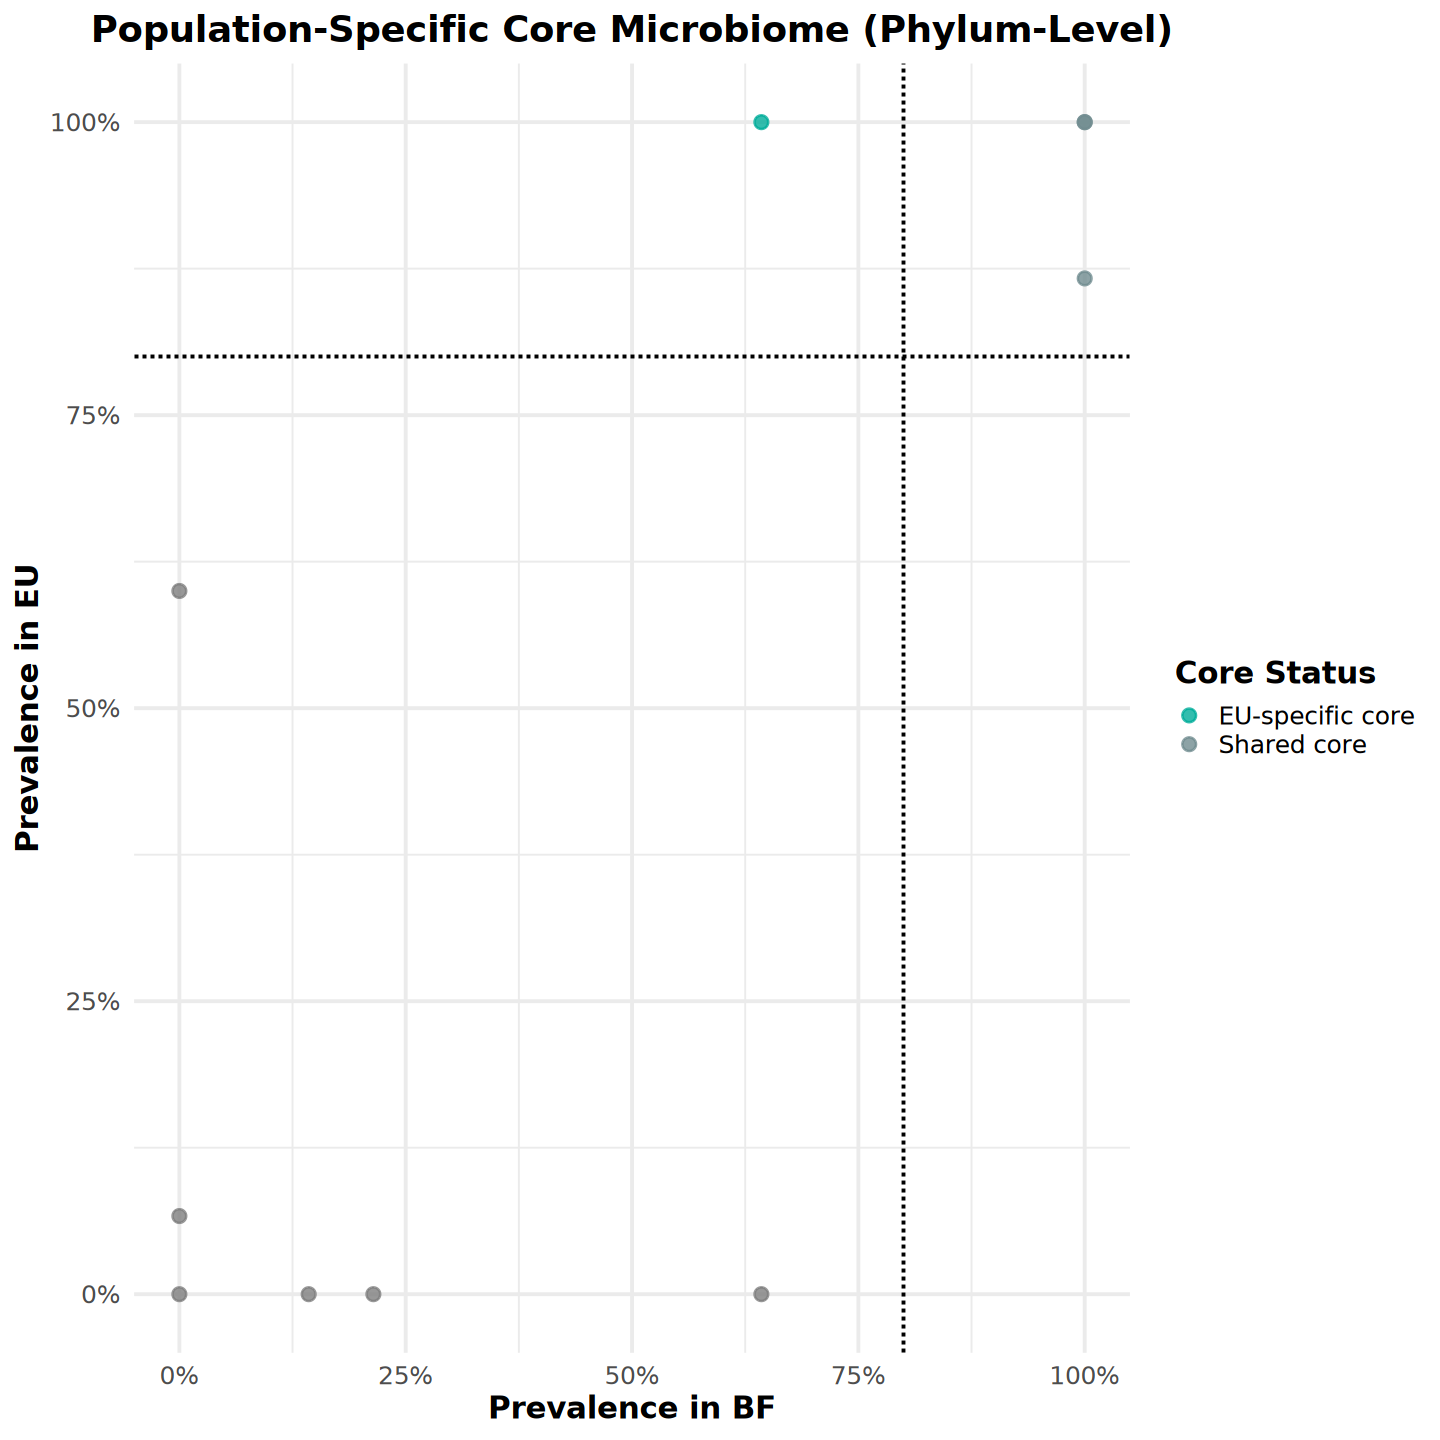

In [151]:

core_df_phylum_noNA <- core_df_phylum |>
    filter(!is.na(Phylum))


options(repr.plot.width = 12, repr.plot.height = 12)

p_core_phylum <- core_df_phylum_noNA |>
    ggplot(aes(x = BF_prevalence, y = EU_prevalence, color = Core_status)) +
    geom_point(size = 3, alpha = 0.8) +
    geom_vline(xintercept = CORE_PREVALENCE, linetype = "dashed") +
    geom_hline(yintercept = CORE_PREVALENCE, linetype = "dashed") +
    scale_x_continuous(labels = scales::percent, limits = c(0, 1)) +
    scale_y_continuous(labels = scales::percent, limits = c(0, 1)) +
    scale_color_manual(values = pop_core_colors) +
    labs(
        x = "Prevalence in BF",
        y = "Prevalence in EU",
        color = "Core Status",
        title = "Population-Specific Core Microbiome (Phylum-Level)"
    ) +
    theme_minimal(base_size = 18) +
    theme(
        plot.title = element_text(face = "bold", hjust = 0.5),
        axis.title = element_text(face = "bold"),
        legend.title = element_text(face = "bold")
    )

p_core_phylum


In [152]:

# Shared core
core_df_phylum |>
    filter(Core_status == "Shared core") |>
    arrange(desc(BF_prevalence + EU_prevalence))

# BF-specific core
core_df_phylum |>
    filter(Core_status == "BF-specific core") |>
    arrange(desc(BF_prevalence))

# EU-specific core
core_df_phylum |>
    filter(Core_status == "EU-specific core") |>
    arrange(desc(EU_prevalence))
	
	

Phylum,BF_prevalence,EU_prevalence,BF_core,EU_core,Core_status
<chr>,<dbl>,<dbl>,<lgl>,<lgl>,<chr>
Bacillota,1,1.0000000,TRUE,TRUE,Shared core
Pseudomonadota,1,1.0000000,TRUE,TRUE,Shared core
Bacteroidota,1,0.8666667,TRUE,TRUE,Shared core


Phylum,BF_prevalence,EU_prevalence,BF_core,EU_core,Core_status
<chr>,<dbl>,<dbl>,<lgl>,<lgl>,<chr>


Phylum,BF_prevalence,EU_prevalence,BF_core,EU_core,Core_status
<chr>,<dbl>,<dbl>,<lgl>,<lgl>,<chr>
Actinomycetota,0.6428571,1,FALSE,TRUE,EU-specific core


In [153]:

	
core_df_phylum_noNA_noShared <- core_df_phylum_noNA |>
    filter(BF_core | EU_core) |>
    select(Phylum, BF_core, EU_core)

core_df_phylum_noNA_noShared


Phylum,BF_core,EU_core
<chr>,<lgl>,<lgl>
Actinomycetota,FALSE,TRUE
Bacillota,TRUE,TRUE
Bacteroidota,TRUE,TRUE
Pseudomonadota,TRUE,TRUE


In [154]:

core_df_phylum_noNA_noShared <- core_df_phylum_noNA_noShared |>
    filter(BF_core | EU_core) |>
    transmute(
        Phylum,
        BF = BF_core,
        EU = EU_core
    )


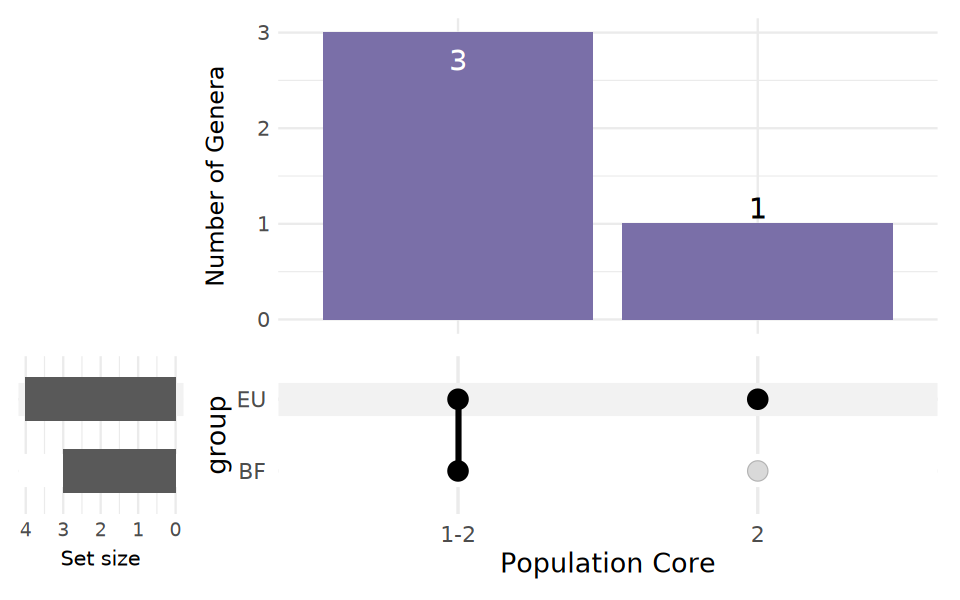

In [155]:

options(repr.plot.width = 8, repr.plot.height = 5)
p_core_upset_phylum <- upset(
    core_df_phylum_noNA_noShared,
    c("BF", "EU"),
    name = "Population Core",
    width_ratio = 0.2,

     base_annotations = list(
        "Number of Genera" = (
            intersection_size(fill = "#7A6FA8", 
                              text = list(size = 6)
                             ) +
            theme(
                axis.title.y = element_text( # 'number of genera'
                    size = 14,
                    # face = "bold"
                ),
                axis.text.y = element_text( # nubmer of genera ticks
                    size = 12,
                    # face = "bold"
                )
            )
        )
    ),

    matrix = intersection_matrix(
        geom = geom_point(size = 4),
        segment = geom_segment(linewidth = 1.2)
    ),

    set_sizes = (
        upset_set_size() +
        theme(
            axis.title.x = element_text( # Set Size
                size = 12,
                # face = "bold"
            ),
            axis.text.x = element_text(size = 11)
        )
    )

    
) +
    theme(
        text = element_text(size = 18, color = "black"),
        axis.text = element_text(size = 20, color = "black"),
        axis.title = element_text(size = 20, face = "bold", color = "black"),
        plot.title = element_text(size = 20, face = "bold", color = "black"),
       axis.title.y  = element_text(size = 20, face = "bold", color = "black"),
        axis.text.y = element_text(size = 22,face = "bold"),
        
        # text = list(size = 8),
        panel.grid.major = element_line(
            color = "grey70",
            linewidth = 0.6
        ),
        panel.grid.minor = element_blank()
    )   +   
theme_minimal(base_size = 16) 



p_core_upset_phylum



In [156]:

# ggsave(
#     filename = paste0(FIG_CORE_MICROBIOME_DIR, '/', PROJECT_NAME, '.core_micro.phylum.sensitivity_test.png'),
#     plot = p_core_upset_phylum,
#     width = 8,
#     height = 8,
#     units = "in",
#     dpi = 300,
#     bg = "white"
# )

# ggsave(
#     filename = paste0(FIG_CORE_MICROBIOME_DIR, '/', PROJECT_NAME, '.core_micro.phylum.sensitivity_test.pdf'),
#     plot = p_core_upset_phylum,
#     width = 8,
#     height = 8,
#     units = "in",
#     bg = "white"
# )


# # save table for quarto plot
# write_tsv( 
#     core_df_phylum_noNA_noShared,
#     file = file.path(QUARTO_PLOT_TABLE_DIR, paste0(PROJECT_NAME, ".core_micro.phylum.sensitivity_test.summary.tsv")),
#     quote = "needed"
# )



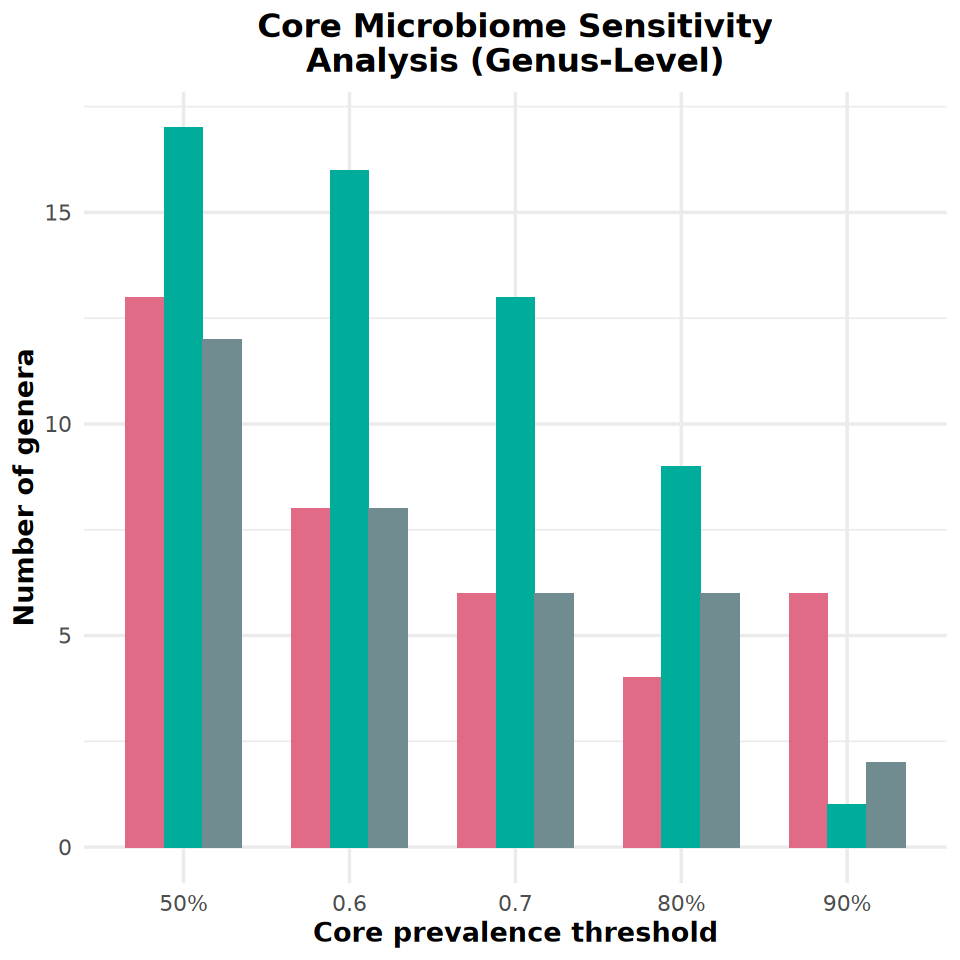

In [170]:
options(repr.plot.width = 8, repr.plot.height = 8)

p_core_sensitivity_genus <- ggplot(
    core_sensitivity_summary_genus,
    aes(
        x = factor(Core_prevalence),
        y = n,
        fill = Core_status
    )
) +
    geom_col(
        position = "dodge",
        width = 0.7
    ) +
    scale_x_discrete(
        labels = c(
            "0.5" = "50%",
            "0.8" = "80%",
            "0.9" = "90%"
        )
    ) +
    labs(
        x = "Core prevalence threshold",
        y = "Number of genera",
        fill = "Core status",
        title = "Core Microbiome Sensitivity\nAnalysis (Genus-Level)"
    ) +
    theme_minimal(base_size = 16) +
    theme(
        plot.title = element_text(
            face = "bold",
            hjust = 0.5
        ),
        legend.position = "none",

        
        axis.title = element_text(face = "bold"),
        legend.title = element_text(face = "bold")
    ) +     scale_fill_manual(values = pop_core_colors) 

p_core_sensitivity_genus

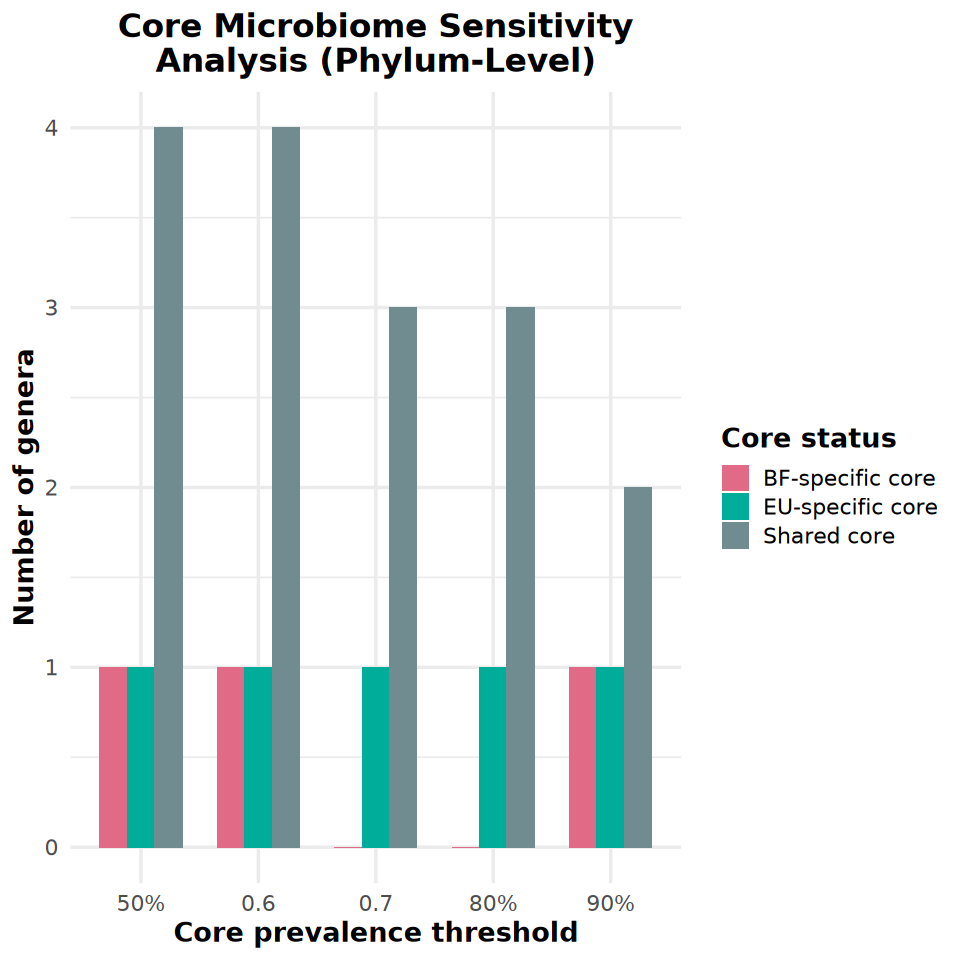

In [167]:



options(repr.plot.width = 8, repr.plot.height = 8)

p_core_sensitivity_phylum <- ggplot(
    core_sensitivity_summary_phylum,
    aes(
        x = factor(Core_prevalence),
        y = n,
        fill = Core_status
    )
) +
    geom_col(
        position = "dodge",
        width = 0.7
    ) +
    scale_x_discrete(
        labels = c(
            "0.5" = "50%",
            "0.8" = "80%",
            "0.9" = "90%"
        )
    ) +
    labs(
        x = "Core prevalence threshold",
        y = "Number of genera",
        fill = "Core status",
        title = "Core Microbiome Sensitivity\nAnalysis (Phylum-Level)"
    ) +
    theme_minimal(base_size = 16) +
    theme(
        plot.title = element_text(
            face = "bold",
            hjust = 0.5
        ),
        axis.title = element_text(face = "bold"),
        legend.title = element_text(face = "bold")
    ) +     scale_fill_manual(values = pop_core_colors) 

p_core_sensitivity_phylum




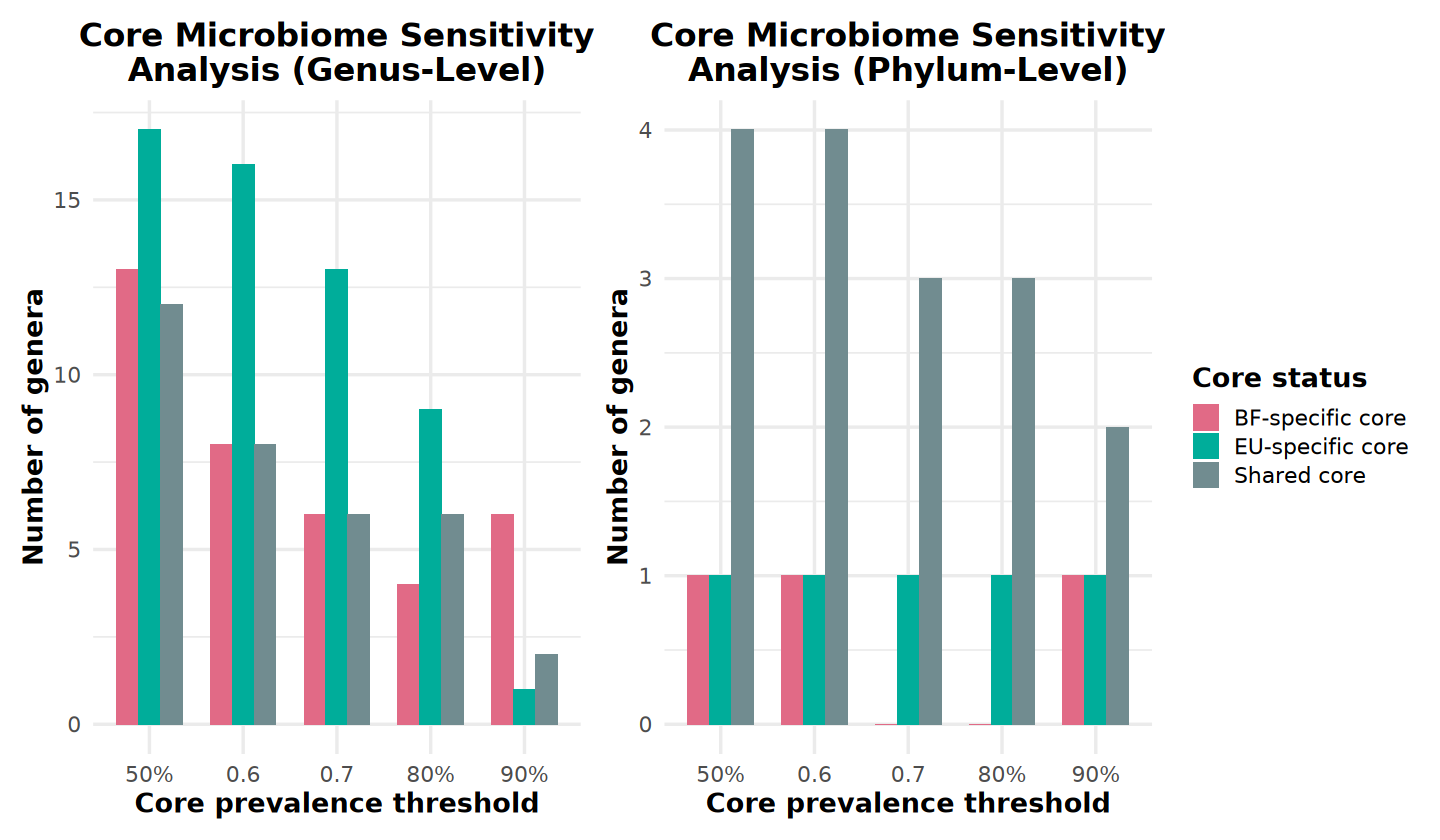

In [172]:
options(repr.plot.width = 12, repr.plot.height = 7)


p_core_sensitivity_both <- p_core_sensitivity_genus +    p_core_sensitivity_phylum
p_core_sensitivity_both

In [174]:

ggsave(
    filename = paste0(FIG_CORE_MICROBIOME_DIR, '/', PROJECT_NAME, '.core_micro.both.sensitivity_test.png'),
    plot = p_core_sensitivity_both,
    width = 12,
    height = 7,
    units = "in",
    dpi = 300,
    bg = "white"
)

ggsave(
    filename = paste0(FIG_CORE_MICROBIOME_DIR, '/', PROJECT_NAME, '.core_micro.both.sensitivity_test.pdf'),
    plot = p_core_sensitivity_both,
    width = 12,
    height = 7,
    units = "in",
    bg = "white"
)

